In [1]:
%%capture
!pip install -U langchain-community pymupdf

In [2]:
import os
import tiktoken
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch.nn as nn, torch
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
from transformers import get_cosine_schedule_with_warmup
from langchain_community.document_loaders import PyMuPDFLoader

from transformers.modeling_outputs import CausalLMOutput
from transformers import PreTrainedModel, PretrainedConfig

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("ggplot")

In [3]:
@dataclass 
class config:
    d_model = 512
    stride = 1024
    seq_len = 1024
    batch_size = 1
    num_head = 16
    n_vocabs = 50257
    lr = 1e-4
    n_epochs = 50
    n_blocks = 12

    device_0 = "cuda:0"
    device_1 = "cuda:1"

    tokenizer = tiktoken.get_encoding("gpt2")
    pdf_pth = "/kaggle/input/datasets/edifonjimmy/diabetes-guideline/Guideline-For-Diabetes-Management-In-Nigeria-2nd-Edition.pdf"

In [4]:
loader = PyMuPDFLoader(file_path=config.pdf_pth)

doc = loader.load()

In [5]:
text = ""
for ext_doc in doc:
    text += " " + ext_doc.page_content

text = text.strip()

In [6]:
total_token = len(text)
train_size = 0.9

train_text = text[ : int(train_size * total_token)]
val_text = text[int(train_size * total_token) : ]

In [7]:
class TextDataset(Dataset):
    def __init__(self, text, config):
        token_ids = config.tokenizer.encode(text, allowed_special={"<|endoftext|>"})
        self.X, self.y = [], []
        for idx in range(0, len(token_ids)- config.seq_len, config.seq_len):
            x_token, y_token = token_ids[idx : idx+config.seq_len], token_ids[idx+1 : idx+config.seq_len+1]
            self.X.append(x_token)
            self.y.append(y_token)
            
    def __len__(self): 
        return len(self.X)

    def __getitem__(self, idx): 
        return torch.tensor(self.X[idx]) , torch.tensor(self.y[idx])

In [8]:
train_ds = TextDataset(text=train_text, config=config)
train_dl =  DataLoader(train_ds, batch_size=config.batch_size, shuffle=True, num_workers=os.cpu_count())

val_ds = TextDataset(text=val_text, config=config)
val_dl =  DataLoader(val_ds, batch_size=config.batch_size, shuffle=False, num_workers=os.cpu_count())

In [9]:
batch_x, batch_y = next(iter(train_dl))

print(batch_x.shape, batch_y.shape)

torch.Size([1, 1024]) torch.Size([1, 1024])


In [10]:
class SinusodalPE(nn.Module):
    def __init__(self, config):
        super().__init__()
        pe = torch.zeros(config.seq_len, config.d_model)
        pos = torch.arange(config.seq_len).unsqueeze(1) # [seq_len, 1]
        inv_freq = torch.exp((torch.arange(0, config.d_model, 2) * torch.log(torch.tensor(10_000)))/config.d_model) # [d_model/2]
        mat_mul = pos * inv_freq # [seq_len, d_model/2]

        pe[:, 0::2] = torch.sin(mat_mul) # [seq_len, d_model/2]
        pe[:, 1::2] = torch.cos(mat_mul) # [seq_len, d_model/2]

        self.register_buffer("pe", pe.unsqueeze(0)) # [1, seq_len, d_model]

    @property
    def name(self):
        return "sinusodal_pe"

    def forward(self, x):
        # x -> (batch_size, seq_len, d_model)
        return x + self.pe[:, :x.shape[1]] 


class RotationalPE(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.d_model % config.num_head == 0 , f"{config.d_model} % {config.num_head} != 0"
        self.config = config
        self.d_k = config.d_model //  config.num_head
        pos = torch.arange(config.seq_len).unsqueeze(1) # [seq_len, 1]
        inv_freq = torch.exp((torch.arange(0, self.d_k, 2) * torch.log(torch.tensor(10_000)))/self.d_k) # [d_k/2]
        mat_mul = pos * inv_freq # [seq_len, d_k/2]

        self.register_buffer("cos", mat_mul.cos())  # [seq_len, d_k/2] 
        self.register_buffer("sin", mat_mul.sin()) # [seq_len, d_k/2]

    @property
    def name(self):
        return "rotational_pe"

    def forward(self, x):
        # (B, num_head, SEQ_LEN, d_k)
        seq_len = x.shape[-2]
        x1, x2 = x[..., 0::2], x[..., 1::2] # (B, num_head, SEQ_LEN, d_k/2)
        sin = self.sin[:seq_len, :][None, None, :, :] # (1, 1, seq_len, d_k/2)
        cos = self.cos[:seq_len, :][None, None, :, :] # # (1, 1, seq_len, d_k/2)

        x1_rot = x1 * cos - x2 * sin # (B, num_head, SEQ_LEN, d_k/2)
        x2_rot = x1 * sin + x2 * cos # (B, num_head, SEQ_LE, d_k/2)

        x_stack = torch.stack([x1_rot, x2_rot], dim=-1) # (B, num_head, SEQ_LEN, d_k/2, 2)

        return x_stack.flatten(-2) # (B, SEQ_LEN, num_head ,d_k/2, 2) -> (B, num_head, SEQ_LEN ,d_k)

class AbsolutePE(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.abs_pe = nn.Embedding(config.seq_len, config.d_model)

    @property
    def name(self):
        return "absolute_pe"

    def forward(self, x):
        # (batch_size, seq_len, d_model)
        B, SEQ_LEN, D_MODEL = x.shape
        pos = torch.arange(SEQ_LEN, device=x.device) # [SEQ_LEN]
        return x+self.abs_pe(pos) # (batch_size, seq_len, d_model) + (SEQ_LEN, D_MODEL)

class RelativePE(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.k = config.seq_len - 1
        self.n_vocab = 2*self.k + 1
        self.rel_emb = nn.Embedding(self.n_vocab, config.d_model)
        self.out_proj = nn.Linear(config.d_model, config.num_head, bias=False)

    @property
    def name(self):
        return "relative_pe"

    def forward(self, x):
        # (batch_size, seq_len, d_model)
        B, SEQ_LEN, D_MODEL = x.shape
        pos = torch.arange(SEQ_LEN, device=x.device) # [SEQ_LEN]
        rel_pos = pos.unsqueeze(0) - pos.unsqueeze(1) # [SEQ_LEN, SEQ_LEN] , range [-(k), k]
        rel_pos = (rel_pos + self.k).long() # shift to [0, 2k], cast to Long
        bias = self.rel_emb(rel_pos) # [SEQ_LEN, SEQ_LEN, d_model]
        bias = self.out_proj(bias) # [SEQ_LEN, SEQ_LEN, num_head]
        return bias.permute(2, 0, 1).unsqueeze(0) # (B, num_head, SEQ_LEN, SEQ_LEN)
    
class MaskedMultiheadAttention(nn.Module):
    def __init__(self, config, pe):
        super().__init__()
        assert config.d_model % config.num_head == 0 , f"{config.d_model} % {config.num_head} != 0"
        self.config = config
        self.pe = pe
        self.d_k = config.d_model //  config.num_head
        self.qkv = nn.Linear(config.d_model, 3*config.d_model)

    def _get_qkv(self, x):
        # (batch_size, seq_len, d_model)
        B, seq_lth, D_MODEL = x.shape
        qkv = self.qkv(x).view(B, self.config.num_head, 3, seq_lth, self.d_k) # (B, SEQ_LEN,3, num_head, d_k)
        return qkv.unbind(2) # (B, seq_lth, num_head, d_k)

    def forward(self, x):
        # x -> (batch_size, seq_len, d_model)
        B, seq_lth, D_MODEL = x.shape
        
        match self.pe.name:
            case "sinusodal_pe":
                x = self.pe(x) # (batch_size, seq_len, d_model)
                q, k, v = self._get_qkv(x) # (B, num_head, SEQ_LEN, d_k)
                
            case "rotational_pe":
                q, k, v = self._get_qkv(x)  # (B, num_head, SEQ_LEN, d_k)
                q, k = self.pe(q), self.pe(k) # (B, num_head, SEQ_LEN, d_k)

            case "absolute_pe":
                x = self.pe(x)
                q, k, v = self._get_qkv(x) # (B, num_head, SEQ_LEN, d_k)

            case "relative_pe":
                bias = self.pe(x)
                q, k, v = self._get_qkv(x)

        # (B, num_head, SEQ_LEN, d_k) @ (B, num_head, d_k, SEQ_LEN) -> (B, num_head, SEQ_LEN, SEQ_LEN)
        attn_scr = (q @ k.transpose(-2, -1)) / self.d_k**0.5 # (B, num_head, SEQ_LEN, SEQ_LEN)

        if self.pe.name == "relative_pe":
            attn_scr = attn_scr + bias # (B, num_head, SEQ_LEN, SEQ_LEN)

        mask =  torch.tril(torch.ones(seq_lth, seq_lth, device=x.device)) # (seq_lth, seq_lth)

        attn_scr = attn_scr.masked_fill(mask==0, -torch.inf) # (B, num_head, SEQ_LEN, SEQ_LEN)

        attn_scr = nn.functional.softmax(attn_scr, dim=-1) @ v # (B, num_head, SEQ_LEN, d_k)
        
        return attn_scr.transpose(1, 2).flatten(-2) # (B, SEQ_LEN, d_model)


class GPT2Transformer(nn.Module):
    def __init__(self, config, pe, mask_attention):
        super().__init__()
        self.config = config
        self.mask_attention = mask_attention
        self.ln1 = nn.LayerNorm(config.d_model)
        self.ln2 = nn.LayerNorm(config.d_model)
        self.ff = nn.Sequential(
            nn.Linear(config.d_model, 4*config.d_model),
            nn.GELU(),
            nn.Linear(4*config.d_model, config.d_model)
        )

    def forward(self, x):
        x = x + self.mask_attention(self.ln1(x)) # (B, SEQ_LEN, d_model)
        x = x + self.ff(self.ln2(x))
        return x # (B, SEQ_LEN, d_model)

class GPT2(nn.Module):
    def __init__(self, block, pe, config):
        super().__init__()
        self.pe = pe
        self.config = config
        self.wrd_embed = nn.Embedding(config.n_vocabs, config.d_model)
        self.out_proj = nn.Linear(config.d_model, config.n_vocabs)
        n_blocks = 3 if pe(config=config).name == "relative_pe" else 12
        self.block = nn.Sequential(*[
            block(config=config,
                  pe=pe(config=config),
                  mask_attention=MaskedMultiheadAttention(config=config,
                                                          pe=pe(config=config))) for _ in range(n_blocks)
        ])

    @property
    def name(self):
        return self.pe(config=config).name

    def forward(self, x):
        # x -> (SEQ_LEN, seq_len)
        x = self.wrd_embed(x) # (batch_size, SEQ_LEN, d_model)
        x = self.block(x) # (B, SEQ_LEN, d_model)
        x = self.out_proj(x) # (B, SEQ_LEN, N_VOCAL)
        return  x

In [11]:
gpt2_sinusodal = GPT2(block = GPT2Transformer,
                      config=config,
                      pe = SinusodalPE)

gpt2_sinusodal

GPT2(
  (wrd_embed): Embedding(50257, 512)
  (out_proj): Linear(in_features=512, out_features=50257, bias=True)
  (block): Sequential(
    (0): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): SinusodalPE()
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
      )
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=512, out_features=2048, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=2048, out_features=512, bias=True)
      )
    )
    (1): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): SinusodalPE()
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
      )
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
 

In [12]:
gpt2_relational = GPT2(block = GPT2Transformer,
                       config=config,
                       pe=RelativePE)

gpt2_relational

GPT2(
  (wrd_embed): Embedding(50257, 512)
  (out_proj): Linear(in_features=512, out_features=50257, bias=True)
  (block): Sequential(
    (0): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): RelativePE(
          (rel_emb): Embedding(2047, 512)
          (out_proj): Linear(in_features=512, out_features=16, bias=False)
        )
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
      )
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=512, out_features=2048, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=2048, out_features=512, bias=True)
      )
    )
    (1): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): RelativePE(
          (rel_emb): Embedding(2047, 512)
          (out_proj): Linear(in_features=512, out_features=16, bias=Fal

In [13]:
gpt2_rotational = GPT2(block = GPT2Transformer,
                       config=config,
                       pe=RotationalPE)

gpt2_rotational

GPT2(
  (wrd_embed): Embedding(50257, 512)
  (out_proj): Linear(in_features=512, out_features=50257, bias=True)
  (block): Sequential(
    (0): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): RotationalPE()
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
      )
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=512, out_features=2048, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=2048, out_features=512, bias=True)
      )
    )
    (1): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): RotationalPE()
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
      )
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(

In [14]:
gpt2_absolute = GPT2(block=GPT2Transformer,
                     config=config,
                     pe=AbsolutePE)

gpt2_absolute

GPT2(
  (wrd_embed): Embedding(50257, 512)
  (out_proj): Linear(in_features=512, out_features=50257, bias=True)
  (block): Sequential(
    (0): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): AbsolutePE(
          (abs_pe): Embedding(1024, 512)
        )
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
      )
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=512, out_features=2048, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=2048, out_features=512, bias=True)
      )
    )
    (1): GPT2Transformer(
      (mask_attention): MaskedMultiheadAttention(
        (pe): AbsolutePE(
          (abs_pe): Embedding(1024, 512)
        )
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
      )
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=

In [15]:
criterion = nn.CrossEntropyLoss()

optimizer_sinusodal = torch.optim.AdamW(params=gpt2_sinusodal.parameters(), lr=config.lr)
optimizer_relational = torch.optim.AdamW(params=gpt2_relational.parameters(), lr=config.lr)
optimizer_rotational = torch.optim.AdamW(params=gpt2_rotational.parameters(), lr=config.lr)
optimizer_absolute = torch.optim.AdamW(params=gpt2_absolute.parameters(), lr=config.lr)

num_training_steps = config.n_epochs * len(train_dl)
num_warmup_steps = int(0.1 * num_training_steps) 

lr_scheduler_sinusodal = get_cosine_schedule_with_warmup(
    optimizer=optimizer_sinusodal,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)
lr_scheduler_relational = get_cosine_schedule_with_warmup(
    optimizer=optimizer_relational,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)
lr_scheduler_rotational = get_cosine_schedule_with_warmup(
    optimizer=optimizer_rotational,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)
lr_scheduler_absolute = get_cosine_schedule_with_warmup(
    optimizer=optimizer_absolute,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [16]:
class Trainer:
    def __init__(self, train_dl, val_dl, model, optimizer, criterion, lr_scheduler):
        self.train_dl = train_dl
        self.val_dl = val_dl
        self.optimizer = optimizer 
        self.criterion = criterion
        self.lr_scheduler = lr_scheduler
        self.device = (
               model.config.device_0 if model.name == "sinusodal_pe"
               else model.config.device_1 if model.name == "rotational_pe"
               else model.config.device_0 if model.name == "relative_pe"
               else model.config.device_1 
        )
        self.model = model.to(self.device)

        self.patience = 5
        self.count = 0
        self.best_weight = None
        self.best_val_loss = float("inf")

    def train(self):
        total_loss = 0

        self.model.train()
        for batch_X, batch_Y in self.train_dl:
            # y->(BATCH_SIZE, SEQ_LEN) X->((BATCH_SIZE, SEQ_LEN))
            batch_X, batch_Y = batch_X.to(self.device), batch_Y.to(self.device)
            
            self.optimizer.zero_grad()
            logits = self.model(batch_X) #  (B, SEQ_LEN, N_VOCAL) 
            loss = self.criterion(logits.flatten(0, 1), batch_Y.flatten())
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss+=loss.item()

        return total_loss / len(self.train_dl)

    def eval(self):
        total_loss = 0

        self.model.eval()
        with torch.no_grad():
            for batch_X, batch_Y in self.val_dl:
                # y->(BATCH_SIZE, SEQ_LEN) X->((BATCH_SIZE, SEQ_LEN))
                batch_X, batch_Y = batch_X.to(self.device), batch_Y.to(self.device)
        
                logits = self.model(batch_X) #  (B, SEQ_LEN, N_VOCAL) 
                loss = self.criterion(logits.flatten(0, 1), batch_Y.flatten())
    
                total_loss+=loss.item()

        return total_loss / len(self.val_dl)

    def _early_stopping(self, val_loss):
        if val_loss < self.best_val_loss - 1e-6:
            self.best_val_loss = val_loss
            self.count = 0
            self.best_weight = self.model.state_dict()
            return False
        else:
            self.count += 1
            return self.count >= self.patience

    def fit(self):
        progress_bar = tqdm(range(1, self.model.config.n_epochs+1),
                            total=self.model.config.n_epochs,
                            desc="Training...")

        results = {"train_loss":[], "val_loss":[], "epochs":[]}        
        for epoch in progress_bar:
            train_loss, val_loss = self.train(), self.eval()
            self.lr_scheduler.step()

            results["train_loss"].append(train_loss)
            results["val_loss"].append(val_loss)
            results["epochs"].append(epoch)
            
            progress_bar.set_postfix({"epoch":epoch, "train_loss":train_loss, "val_loss":val_loss}, refresh=True)

            if self._early_stopping(val_loss=val_loss):
                if self.best_weight is not None:
                    torch.save(self.best_weight, f"{self.model.name}.pt")
                break

        return pd.DataFrame(results)

In [17]:
def GenerateText(model, text, max_new_tokens=50, context_size=1024, 
                 tokenizer=None, top_k=50, temperature=1.0):
    model.eval()
    token_ids = torch.tensor(tokenizer.encode(text)).unsqueeze(0).to(next(model.parameters()).device)
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            idx_crop = token_ids[:, -context_size:]
            logits = model(idx_crop)                        # (B, seq_len, vocab_size)
            logits = logits[:, -1, :] / temperature         # (B, vocab_size) — last token only

            # clamp to valid vocab range before anything else
            logits = logits[:, :tokenizer.n_vocab]

            # top-k filtering
            if top_k is not None:
                top_vals, _ = torch.topk(logits, top_k)
                logits[logits < top_vals[:, -1:]] = -torch.inf

            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # (B, 1)
            token_ids = torch.cat((token_ids, next_token), dim=1)

    return tokenizer.decode(token_ids[0].tolist())

Training...:  72%|███████▏  | 36/50 [09:45<03:47, 16.26s/it, epoch=37, train_loss=4.75, val_loss=7.34]


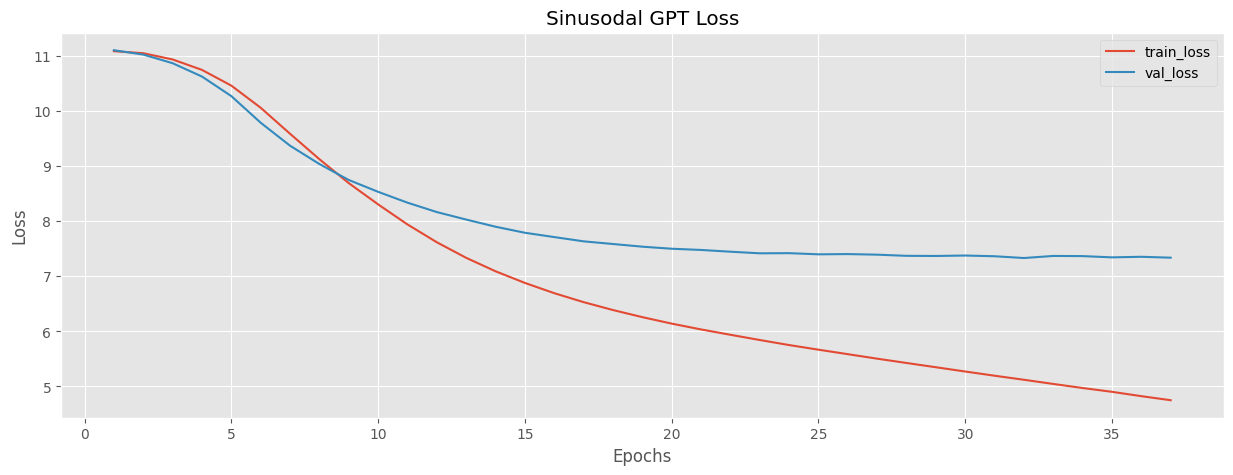

In [18]:
trainer_sinusodal = Trainer(train_dl=train_dl, 
                            val_dl=val_dl,
                            model=gpt2_sinusodal,
                            optimizer=optimizer_sinusodal,
                            criterion=criterion, 
                            lr_scheduler=lr_scheduler_sinusodal)

trainer_sinusodal_result = trainer_sinusodal.fit()

trainer_sinusodal_result.set_index("epochs").plot(figsize=(15, 5), 
                                                  xlabel="Epochs",
                                                  ylabel="Loss", 
                                                  title="Sinusodal GPT Loss")
plt.show()

In [19]:
gpt2_sinusodal_init = GPT2(block = GPT2Transformer,
                           config=config,
                           pe=SinusodalPE)

gpt2_sinusodal_trained_state_dict = torch.load("/kaggle/working/sinusodal_pe.pt")

gpt2_sinusodal_init.load_state_dict(gpt2_sinusodal_trained_state_dict)

test_text = "The management of Diabetes Millitus (DM) has always been"

GenerateText(model=gpt2_sinusodal_init, text=test_text, tokenizer=config.tokenizer)

'The management of Diabetes Millitus (DM) has always been shown to\nTheDM not\nPeople insulin related\nof patients with diabetes.7. \n>\n\uf0b7\n\uf0b7\nA Diabetes from the\n8. This – 4) of insulin that patients (2ing blood pressure'

Training...:  74%|███████▍  | 37/50 [10:10<03:34, 16.49s/it, epoch=38, train_loss=4.71, val_loss=7.33]


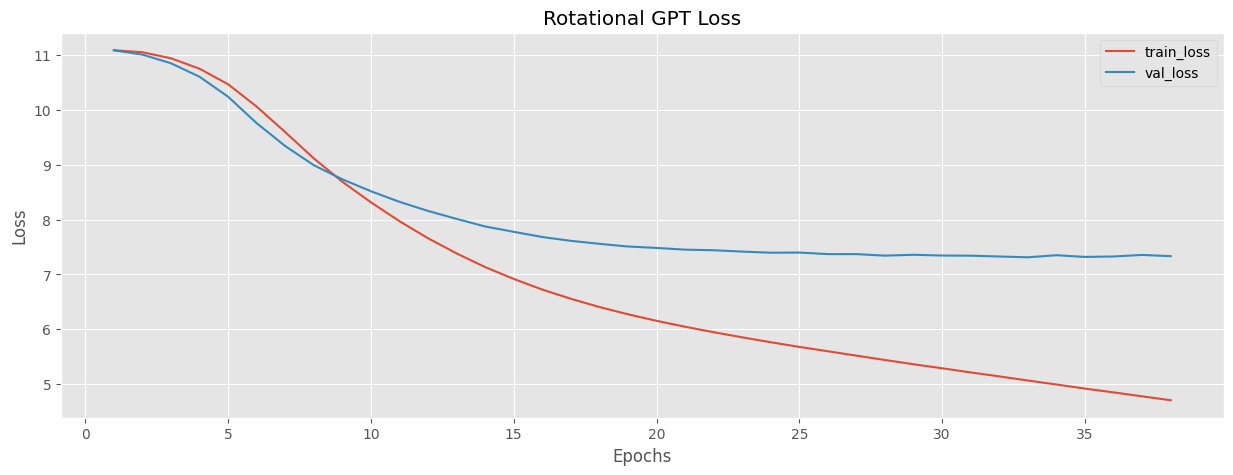

In [20]:
trainer_rotational = Trainer(train_dl=train_dl, 
                            val_dl=val_dl,
                            model=gpt2_rotational,
                            optimizer=optimizer_rotational,
                            criterion=criterion, 
                            lr_scheduler=lr_scheduler_rotational)

trainer_rotational_result = trainer_rotational.fit()

trainer_rotational_result.set_index("epochs").plot(figsize=(15, 5), 
                                                   xlabel="Epochs",
                                                   ylabel="Loss", 
                                                   title="Rotational GPT Loss")
plt.show()

In [21]:
gpt2_rotational_init = GPT2(block = GPT2Transformer,
                            config=config,
                            pe=RotationalPE)

gpt2_rotational_trained_state_dict = torch.load("/kaggle/working/rotational_pe.pt")

gpt2_rotational_init.load_state_dict(gpt2_rotational_trained_state_dict)

test_text = "The management of Diabetes Millitus (DM) has always been"

GenerateText(model=gpt2_rotational_init,
             text=test_text, 
             tokenizer=config.tokenizer)

'The management of Diabetes Millitus (DM) has always been disorder and\n2, or type 1 to the\n-up-up it is common and have such 3 fasting glucose\n11.3-\n9.5%\na of diabetes in\ndiabetes.2 Treatment\nThe new.\n'

Training...:  78%|███████▊  | 39/50 [10:49<03:03, 16.66s/it, epoch=40, train_loss=4.5, val_loss=7.35] 


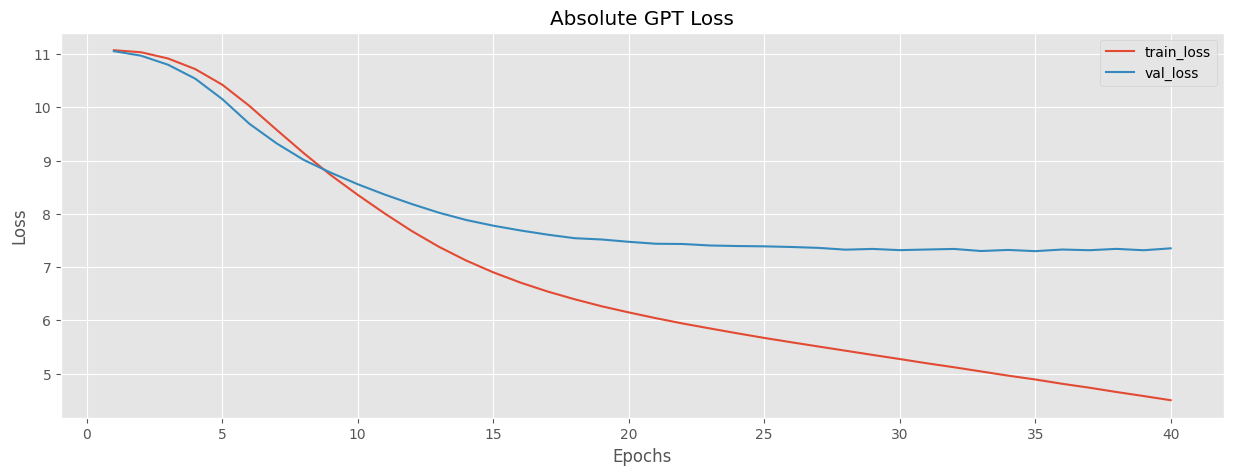

In [22]:
trainer_absolute = Trainer(train_dl=train_dl, 
                            val_dl=val_dl,
                            model=gpt2_absolute,
                            optimizer=optimizer_absolute,
                            criterion=criterion, 
                            lr_scheduler=lr_scheduler_absolute)

trainer_absolute_result = trainer_absolute.fit()

trainer_absolute_result.set_index("epochs").plot(figsize=(15, 5), 
                                                 xlabel="Epochs",
                                                 ylabel="Loss", 
                                                 title="Absolute GPT Loss")
plt.show()

In [23]:
gpt2_absolute_init = GPT2(block=GPT2Transformer,
                          config=config,
                          pe=AbsolutePE)

gpt2_absolute_trained_state_dict = torch.load("/kaggle/working/absolute_pe.pt")

gpt2_absolute_init.load_state_dict(gpt2_absolute_trained_state_dict)

test_text = "The management of Diabetes Millitus (DM) has always been"

GenerateText(model=gpt2_absolute_init, text=test_text, tokenizer=config.tokenizer)

"The management of Diabetes Millitus (DM) has always been adopted patients of self at the patient's is <7\nHg.8% fat 5 years.1.\n6\n1. \n5 (10. NCDs and\n\uf0b7\n1 (0.6. The"

Training...:  98%|█████████▊| 49/50 [17:47<00:21, 21.79s/it, epoch=50, train_loss=5.02, val_loss=7.47]


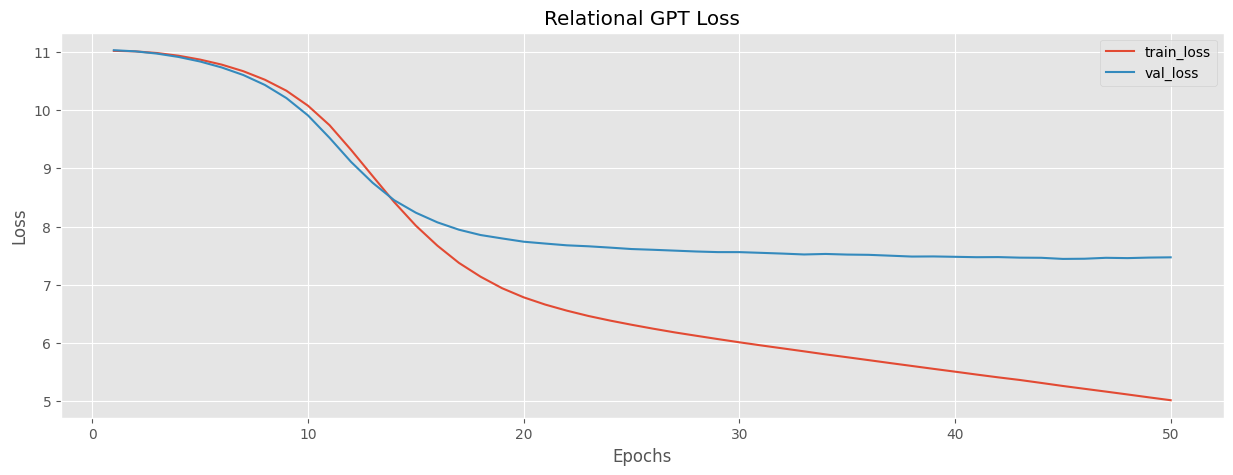

In [24]:
trainer_relational = Trainer(train_dl=train_dl, 
                            val_dl=val_dl,
                            model=gpt2_relational,
                            optimizer=optimizer_relational,
                            criterion=criterion, 
                            lr_scheduler=lr_scheduler_relational)

trainer_relational_result = trainer_relational .fit()

trainer_relational_result.set_index("epochs").plot(figsize=(15, 5), 
                                                   xlabel="Epochs",
                                                   ylabel="Loss", 
                                                   title="Relational GPT Loss")
plt.show()

In [25]:
gpt2_relational_init = GPT2(block=GPT2Transformer,
                            config=config,
                            pe=RelativePE)

gpt2_relational_trained_state_dict = torch.load("/kaggle/working/relative_pe.pt")

gpt2_relational_init.load_state_dict(gpt2_relational_trained_state_dict)

test_text = "The management of Diabetes Millitus (DM) has always been"

GenerateText(model=gpt2_relational_init, text=test_text, tokenizer=config.tokenizer)

'The management of Diabetes Millitus (DM) has always been shown to the\nof-mg\n-off.\n\uf0b7\nmdicated\n\uf0b7\nIn in\npatients with at risk of GDM the initial to\np. NCDs in the initial.2:'

### Convert Model to Transformer

In [26]:
%%writefile modeling_custom_gpt2.py

import sys
import torch
import torch.nn as nn
from transformers import PreTrainedModel, PretrainedConfig
from transformers.modeling_outputs import CausalLMOutput

class SinusodalPE(nn.Module):
    def __init__(self, config):
        super().__init__()
        pe      = torch.zeros(config.seq_len, config.d_model)
        pos     = torch.arange(config.seq_len).unsqueeze(1)
        inv_freq = torch.exp(
            (torch.arange(0, config.d_model, 2) * torch.log(torch.tensor(10_000.0)))
            / config.d_model
        )
        mat_mul = pos * inv_freq
        pe[:, 0::2] = torch.sin(mat_mul)
        pe[:, 1::2] = torch.cos(mat_mul)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, seq_len, d_model)

    @property
    def name(self): return "sinusoidal_pe"

    def forward(self, x):
        return x + self.pe[:, :x.shape[1]]


class RotationalPE(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.d_k = config.d_model // config.num_head
        pos      = torch.arange(config.seq_len).unsqueeze(1)
        inv_freq = torch.exp(
            (torch.arange(0, self.d_k, 2) * torch.log(torch.tensor(10_000.0)))
            / self.d_k
        )
        mat_mul  = pos * inv_freq
        self.register_buffer("cos", mat_mul.cos())  # (seq_len, d_k/2)
        self.register_buffer("sin", mat_mul.sin())  # (seq_len, d_k/2)

    @property
    def name(self): return "rotational_pe"

    def forward(self, x):
        # x: (B, num_head, seq_len, d_k)
        seq_len = x.shape[-2]
        x1, x2  = x[..., 0::2], x[..., 1::2]
        cos = self.cos[:seq_len][None, None]   # (1, 1, seq_len, d_k/2)
        sin = self.sin[:seq_len][None, None]
        x_rot = torch.stack([x1*cos - x2*sin,
                              x1*sin + x2*cos], dim=-1)
        return x_rot.flatten(-2)               # (B, num_head, seq_len, d_k)


class AbsolutePE(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.abs_pe = nn.Embedding(config.seq_len, config.d_model)

    @property
    def name(self): return "absolute_pe"

    def forward(self, x):
        pos = torch.arange(x.shape[1], device=x.device)
        return x + self.abs_pe(pos)


class RelativePE(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.k       = config.seq_len - 1
        self.rel_emb = nn.Embedding(2*self.k + 1, config.d_model)
        self.out_proj = nn.Linear(config.d_model, config.num_head, bias=False)

    @property
    def name(self): return "relative_pe"

    def forward(self, x):
        B, SEQ_LEN, _ = x.shape
        pos     = torch.arange(SEQ_LEN, device=x.device)
        rel_pos = (pos.unsqueeze(0) - pos.unsqueeze(1) + self.k).long()
        bias    = self.out_proj(self.rel_emb(rel_pos))   # (S, S, num_head)
        return bias.permute(2, 0, 1).unsqueeze(0)        # (1, num_head, S, S)


class MaskedMultiheadAttention(nn.Module):
    def __init__(self, config, pe):
        super().__init__()
        assert config.d_model % config.num_head == 0
        self.config = config
        self.pe     = pe
        self.d_k    = config.d_model // config.num_head
        self.qkv    = nn.Linear(config.d_model, 3 * config.d_model)

    def _get_qkv(self, x):
        B, S, D = x.shape
        # correct reshape: (B, S, 3*D) -> (B, S, 3, num_head, d_k) -> (3, B, num_head, S, d_k)
        qkv = (self.qkv(x)
                   .view(B, S, 3, self.config.num_head, self.d_k)
                   .permute(2, 0, 3, 1, 4))   # (3, B, num_head, S, d_k)
        return qkv.unbind(0)                   # q, k, v each (B, num_head, S, d_k)

    def forward(self, x):
        B, S, D = x.shape
        bias = None

        match self.pe.name:
            case "sinusoidal_pe" | "absolute_pe":
                x = self.pe(x)
                q, k, v = self._get_qkv(x)

            case "rotational_pe":
                q, k, v = self._get_qkv(x)
                q, k    = self.pe(q), self.pe(k)

            case "relative_pe":
                bias    = self.pe(x)           # (1, num_head, S, S)
                q, k, v = self._get_qkv(x)

        attn = (q @ k.transpose(-2, -1)) / self.d_k ** 0.5   # (B, num_head, S, S)

        if bias is not None:
            attn = attn + bias

        mask = torch.tril(torch.ones(S, S, device=x.device))
        attn = attn.masked_fill(mask == 0, float("-inf"))
        attn = nn.functional.softmax(attn, dim=-1)

        out = attn @ v                                         # (B, num_head, S, d_k)
        return out.transpose(1, 2).flatten(-2)                 # (B, S, d_model)


class GPT2Transformer(nn.Module):
    def __init__(self, config, pe):
        super().__init__()
        self.attn = MaskedMultiheadAttention(config, pe)
        self.ln1  = nn.LayerNorm(config.d_model)
        self.ln2  = nn.LayerNorm(config.d_model)
        self.ff   = nn.Sequential(
            nn.Linear(config.d_model, 4 * config.d_model),
            nn.GELU(),
            nn.Linear(4 * config.d_model, config.d_model),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


PE_MAP = {
    "sinusoidal_pe": SinusodalPE,
    "rotational_pe": RotationalPE,
    "absolute_pe":   AbsolutePE,
    "relative_pe":   RelativePE,
}

class GPT2Config(PretrainedConfig):
    model_type = "custom_gpt2"

    def __init__(
        self,
        n_vocabs=50257,
        d_model=768,
        num_head=12,
        seq_len=1024,
        n_blocks=12,
        pe_type="sinusoidal_pe",
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.n_vocabs = n_vocabs
        self.d_model  = d_model
        self.num_head = num_head
        self.seq_len  = seq_len
        self.n_blocks = n_blocks
        self.pe_type  = pe_type

class GPT2ForCausalLM(PreTrainedModel):
    config_class     = GPT2Config
    _tied_weights_keys = {"out_proj.weight": "wrd_embed.weight"}

    def __init__(self, config: GPT2Config):
        super().__init__(config)
        pe_cls = PE_MAP[config.pe_type]

        self.wrd_embed = nn.Embedding(config.n_vocabs, config.d_model)
        self.blocks    = nn.Sequential(*[
            GPT2Transformer(config, pe_cls(config))
            for _ in range(config.n_blocks)
        ])
        self.ln_f    = nn.LayerNorm(config.d_model)          # final layer norm
        self.out_proj = nn.Linear(config.d_model, config.n_vocabs, bias=False)
        self.out_proj.weight = self.wrd_embed.weight          # weight tying

        self.post_init()

    # --- HF required hooks for weight tying ---
    def get_input_embeddings(self):  return self.wrd_embed
    def set_input_embeddings(self, v): self.wrd_embed = v
    def get_output_embeddings(self): return self.out_proj
    def set_output_embeddings(self, v): self.out_proj = v

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        x      = self.wrd_embed(input_ids)   # (B, S, D)
        x      = self.blocks(x)              # (B, S, D)
        x      = self.ln_f(x)               # (B, S, D)
        logits = self.out_proj(x)            # (B, S, V)

        loss = None
        if labels is not None:
            loss = nn.functional.cross_entropy(
                logits[:, :-1].contiguous().view(-1, self.config.n_vocabs),
                labels[:, 1:].contiguous().view(-1),
                ignore_index=-100,
            )

        return CausalLMOutput(loss=loss, logits=logits)

Writing modeling_custom_gpt2.py


In [27]:
import importlib, modeling_custom_gpt2
importlib.reload(modeling_custom_gpt2)
from modeling_custom_gpt2 import GPT2Config, GPT2ForCausalLM
from transformers import AutoConfig, AutoModelForCausalLM

AutoConfig.register("custom_gpt2", GPT2Config, exist_ok=True)
AutoModelForCausalLM.register(GPT2Config, GPT2ForCausalLM, exist_ok=True)

config = GPT2Config(n_vocabs=config.n_vocabs, 
                    d_model=config.d_model, 
                    num_head=config.num_head,
                    seq_len=config.seq_len, 
                    n_blocks=config.n_blocks, 
                    pe_type="sinusoidal_pe")

model  = GPT2ForCausalLM(config)
model.save_pretrained("gpt_base_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]